In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
from datetime import datetime
import time
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.optimize import brentq

from datetime import datetime
from pandas.tseries.offsets import BDay
import pandas_datareader.data as pdr


In [2]:
transaction_data = pd.read_excel("./Transaction Data.xlsx")
print(transaction_data.tail())

         Date   Ticker   Asset Type     Shares  Cost/Share ($)  Commn  \
54 2026-02-04    GOOGL  Equity  Buy   0.517084          333.04   0.00   
55 2026-02-04     NVDA  Equity  Buy   0.652914          174.19   0.29   
56 2026-02-04     PLTR  Equity  Buy   0.704670          138.76   0.25   
57 2026-02-04      LYG  Equity  Buy  18.621753            6.16   0.29   
58 2026-02-04  SOL-USD  Crypto  Buy   1.310000           71.69   1.99   

    Total Cost ($)  Unnamed: 8  Unnamed: 9  Unnamed: 10  Unnamed: 11  
54      172.209655  172.209655         NaN          NaN          NaN  
55      114.021090  114.021090         NaN          NaN          NaN  
56       98.030009   98.030009         NaN          NaN          NaN  
57      114.999998  114.999998         NaN          NaN          NaN  
58       95.903900   95.903900         NaN          NaN          NaN  


In [3]:
all_tickers = list(transaction_data['Ticker'].unique())

#Remove delisted stock
blackList = []

filt_tickers = [tick for tick in all_tickers if tick not in blackList]
print("You traded {} different stocks".format(len(all_tickers)))

You traded 11 different stocks


In [4]:
filt_tickers

['FANG',
 'ASTS',
 'BTI',
 'NVDA',
 'PLTR',
 'LYG',
 'BTC-USD',
 'SOL-USD',
 'KO',
 'SUI20947-USD',
 'GOOGL']

In [5]:
final_filtered = transaction_data[~transaction_data.Ticker.isin(blackList)]

# Collect the price history for all tickers

In [6]:
start_date = '2021-01-01'
end_date = datetime.today().strftime("%Y-%m-%d")

raw = yf.download(
    filt_tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

price_data = (
    raw.swaplevel(0, 1, axis=1)   # (Ticker, Field)
       .sort_index(axis=1)
       .stack(level=0)            # Ticker → rows
       .rename_axis(["Date", "Ticker"])
       .reset_index()
       .set_index(["Ticker", "Date"])
       .sort_index()
)


In [7]:
tx = transaction_data.copy()
tx["Date"] = pd.to_datetime(tx["Date"])
tx["Type"] = tx["Type"].str.upper()

# Signed shares & cash flow
tx["Signed_shares"] = tx["Shares"].where(
    tx["Type"] == "BUY", -tx["Shares"])

tx["cash_flow"] = tx["Total Cost ($)"].where(
    tx["Type"] == "SELL", -tx["Total Cost ($)"])

tx.tail(10)

,Date,Ticker,Asset,Type,Shares,Cost/Share ($),Commn,Total Cost ($),Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Signed_shares,cash_flow
49,2025-12-03,KO,Equity,BUY,1.889407,70.80,0.33,134.100016,134.100016,NaN,NaN,NaN,1.889407,-134.100016
50,2025-12-03,GOOGL,Equity,BUY,0.446706,320.86,0.36,143.690087,143.690087,NaN,NaN,NaN,0.446706,-143.690087
51,2025-12-03,BTC-USD,Crypto,BUY,0.001300,92109.02,0.00,119.741726,119.741726,NaN,NaN,NaN,0.001300,-119.741726
52,2026-02-04,BTI,Equity,BUY,1.862478,61.59,0.29,115.000020,115.000020,NaN,NaN,NaN,1.862478,-115.000020
53,2026-02-04,FANG,Equity,BUY,0.482956,169.27,0.20,81.949962,81.949962,NaN,NaN,NaN,0.482956,-81.949962
54,2026-02-04,GOOGL,Equity,BUY,0.517084,333.04,0.00,172.209655,172.209655,NaN,NaN,NaN,0.517084,-172.209655
55,2026-02-04,NVDA,Equity,BUY,0.652914,174.19,0.29,114.021090,114.021090,NaN,NaN,NaN,0.652914,-114.021090
56,2026-02-04,PLTR,Equity,BUY,0.704670,138.76,0.25,98.030009,98.030009,NaN,NaN,NaN,0.704670,-98.030009
57,2026-02-04,LYG,Equity,BUY,18.621753,6.16,0.29,114.999998,114.999998,NaN,NaN,NaN,18.621753,-114.999998
58,2026-02-04,SOL-USD,Crypto,BUY,1.310000,71.69,1.99,95.903900,95.903900,NaN,NaN,NaN,1.310000,-95.903900


In [8]:
close_prices = price_data["Close"]
close_prices.index = close_prices.index.set_levels(
    pd.to_datetime(close_prices.index.levels[1]),
    level=1)

close_prices

Ticker        Date      
ASTS          2021-01-04    12.950000
              2021-01-05    13.090000
              2021-01-06    12.940000
              2021-01-07    12.780000
              2021-01-08    12.690000
                              ...    
SUI20947-USD  2026-03-25     0.967862
              2026-03-26     0.926390
              2026-03-27     0.879399
              2026-03-28     0.858183
              2026-03-29     0.846404
Name: Close, Length: 15402, dtype: float64

# Monthly Buying


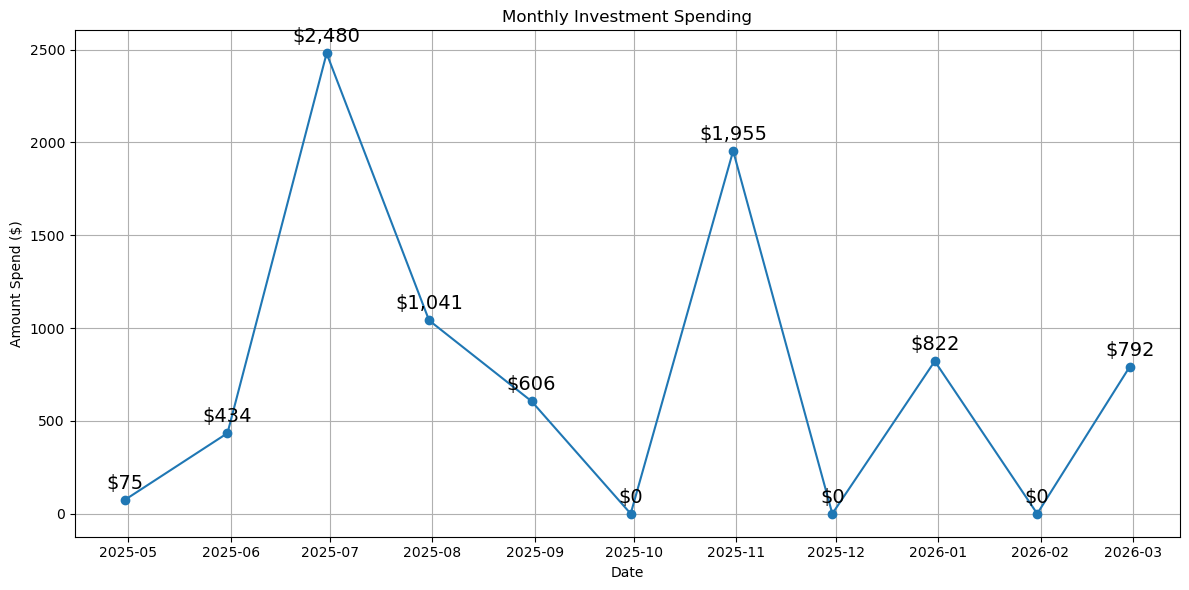

In [9]:
# Keep only Buy transactions 
buy_tx = tx[tx["Type"] == "BUY"].copy()

# Convert to monthy spending
monthly_spending = (buy_tx.set_index("Date").resample("M")["Total Cost ($)"].sum())

# Plot monthly spending
plt.figure(figsize=(12,6))
plt.plot(
    monthly_spending.index, 
    monthly_spending.values,
    marker = "o"
)
plt.title("Monthly Investment Spending")
plt.xlabel("Date")
plt.ylabel("Amount Spend ($)")
plt.grid(True)

# Add value labels
for x, y in zip(monthly_spending.index, monthly_spending.values):
    plt.annotate(
        f"${y:,.0f}",      # format number
        (x, y),            # point location
        textcoords="offset points",
        xytext=(0, 8),     # vertical offset
        ha="center",
        fontsize= 14
    )


plt.tight_layout()
plt.show()

# Net Monthly Cash Flow


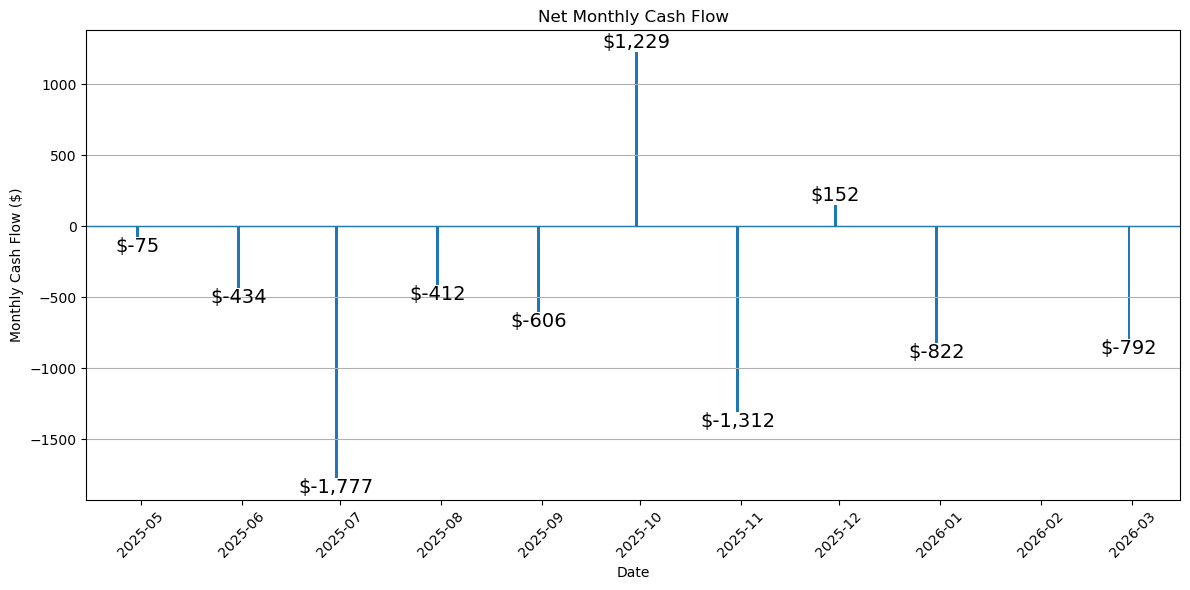

In [10]:
# Convert to Monthy Cash Flow
monthly_net_cf = (tx.set_index("Date").resample("M")["cash_flow"].sum())

# Plot
plt.figure(figsize=(12,6))

plt.bar(
    monthly_net_cf.index,
    monthly_net_cf.values
)

plt.axhline(0, linewidth=1) # Zero line
plt.title("Net Monthly Cash Flow")
plt.xlabel("Date")
plt.ylabel("Monthly Cash Flow ($)")
plt.xticks(rotation=45)
plt.grid(True, axis="y")

# Value Label
for x, y in zip(monthly_net_cf.index, monthly_net_cf.values):
    if y != 0:
        plt.text(
            x,
            y,
            f"${y:,.0f}",
            ha = "center",
            va = "bottom" if y > 0 else "top",
            fontsize = 14
        )
        
plt.tight_layout()
plt.show()

# Portfolio Value

In [11]:
### Already have transaction data tx above:
### Build daily holdings per stock

# First transaction date
start_portfolio_date = tx["Date"].min()
prices = close_prices.unstack("Ticker")
prices = prices.loc[prices.index >= start_portfolio_date]

# Forward-fill missing prices (market-closed days)
prices = prices.ffill().fillna(0)

# Aggregate trades by day and ticker:
daily_trades = (
    tx.groupby(["Date", "Ticker"])["Signed_shares"]
    .sum()
    .unstack("Ticker")
    .fillna(0)
)

# Reindex to daily frequency ad forward-fill holdings
daily_trades = daily_trades.reindex(
    prices.index,
    fill_value=0
)

daily_holdings = daily_trades.cumsum()

### Some issue to remember:
# NaNs are expected due to sparse trades and incomplete price histories.
# - No trade on a date ⇒ 0 shares traded (fill NaNs with 0 before cumsum)
# - Missing prices (IPOs, holidays) ⇒ forward-fill after first valid price
# - Assets only contribute to portfolio value once a position exists
# Explicit handling prevents artificial portfolio value drops.

In [12]:
### Porfolio Value
position_values = (
    prices
    .where(daily_holdings != 0, 0)   # only value when held
    .fillna(0)                       # no price → no valuation
    * daily_holdings
)

portfolio_value = position_values.sum(axis=1)

### Invested Capital
# Daily net cash flow
daily_cash_flow = (
    tx.groupby("Date")["cash_flow"]
    .sum()
    .reindex(portfolio_value.index, fill_value=0)
)

# Cumulative invested capital
invested_capital = (-daily_cash_flow).cumsum()

In [13]:
### Cost Basis Tracking
tx_sorted = tx.sort_values(["Ticker", "Date"]).copy()

records = []
realised_records = []

for ticker, df in tx_sorted.groupby("Ticker"):
    df = df.sort_values("Date")
    
    shares = 0.0
    cost = 0.0
    
    for _, row in df.iterrows():
        date = row["Date"]
        trade_type = row["Type"]
        qty = float(row["Shares"])
        total_cost = float(row["Total Cost ($)"])
        
        if trade_type == "BUY":
            shares += qty
            cost += total_cost
        
        elif trade_type == "SELL":
            if shares > 0:
                avg_cost = cost / shares
                cost_removed = avg_cost * qty
                
                # realised Pnl
                realised = total_cost - cost_removed
                
                realised_records.append({
                    "Date": date,
                    "Ticker": ticker,
                    "Realised_PnL": realised
                })
                
                shares -= qty
                cost -= cost_removed
        
        avg_cost = cost / shares if shares > 0 else 0
        
        records.append({
            "Date": date,
            "Ticker": ticker,
            "Shares": shares,
            "Cost_Basis": cost,
            "Avg_Cost": avg_cost
        })

cost_basis_df = pd.DataFrame(records)

# remove duplicate Date-Ticker rows (take end-of-day state)
cost_basis_df = (
    cost_basis_df
    .sort_values(["Ticker", "Date"])
    .groupby(["Date", "Ticker"], as_index=False)
    .last()
)

# Pivot to daily matrix
cost_basis_pivot = (
    cost_basis_df
    .set_index(["Date", "Ticker"])["Cost_Basis"]
    .unstack("Ticker")
)

# Align with price index
cost_basis_pivot = cost_basis_pivot.reindex(prices.index).ffill().fillna(0)

# Total portfolio cost basis
portfolio_cost_basis = cost_basis_pivot.sum(axis=1)

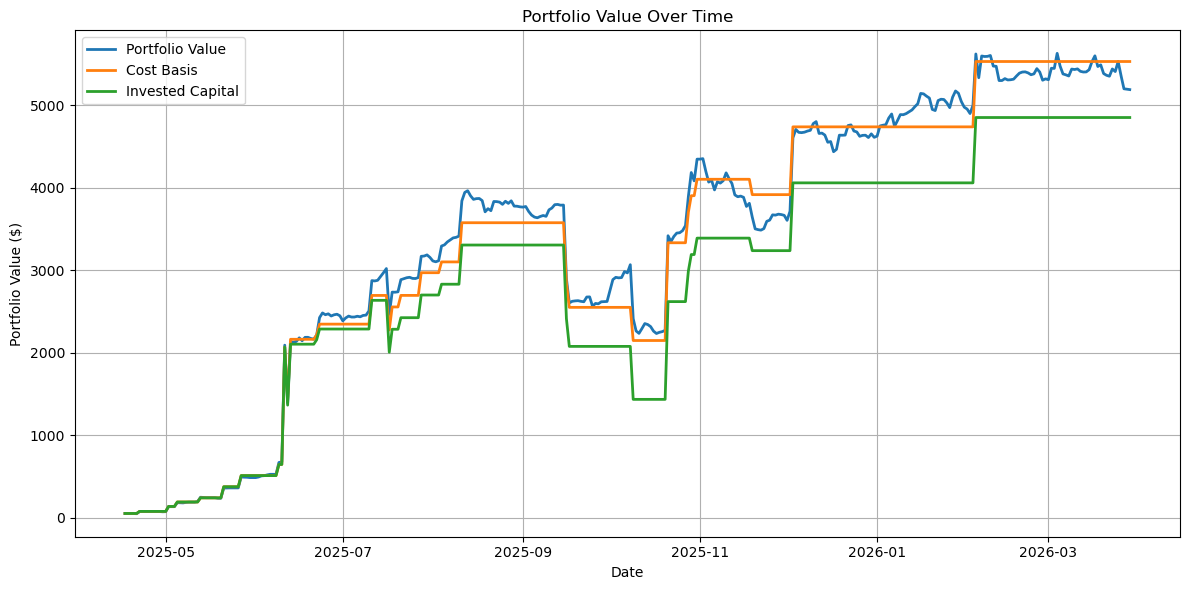

In [14]:


# Plot Portfolio Value + Invested Capital
plt.figure(figsize=(12, 6))

plt.plot(
    portfolio_value.index, 
    portfolio_value.values,
    label="Portfolio Value",
    linewidth=2
)

plt.plot(
    portfolio_cost_basis.index,
    portfolio_cost_basis.values,
    label="Cost Basis",
    linewidth=2
)

plt.plot(
    invested_capital.index,
    invested_capital.values,
    label="Invested Capital",
    linewidth=2
)

plt.title("Portfolio Value Over Time")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Asset Distribution

In [15]:
# Take the lastest date:
latest_date = position_values.index.max()
latest_positions = position_values.loc[latest_date]

# Remove 0 value:
latest_positions = latest_positions[latest_positions > 0]

([<matplotlib.patches.Wedge at 0x295d965ad90>,
 [Text(-0.4666934966004544, 0.9960909497786042, 'Crypto'),
  Text(0.46669349660045384, -0.9960909497786045, 'Equity')],
 [Text(-0.25456008905479327, 0.543322336242875, '13.9%'),
  Text(0.254560089054793, -0.5433223362428751, '86.1%')])

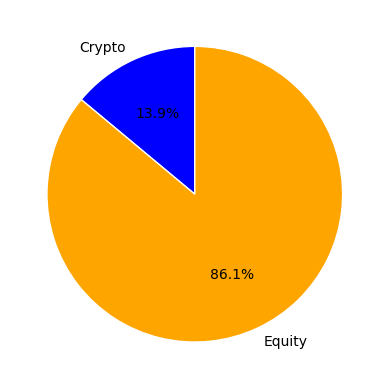

In [16]:
# Mapping asset type
ticker_asset_type = (
    tx[["Ticker", "Asset"]]
    .drop_duplicates()
    .set_index("Ticker")["Asset"]
)

# Aggregate latest portfolio value by asset type
asset_type_values = latest_positions.groupby(
    ticker_asset_type.loc[latest_positions.index]
).sum()

# Define colors by asset type (aligned with index order)
colors = [
    "orange" if asset == "Equity" else "blue"
    for asset in asset_type_values.index
]


# Distribution by Asset Type (Pie Chart - %)
plt.pie(
    asset_type_values,
    labels=asset_type_values.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white"}
)

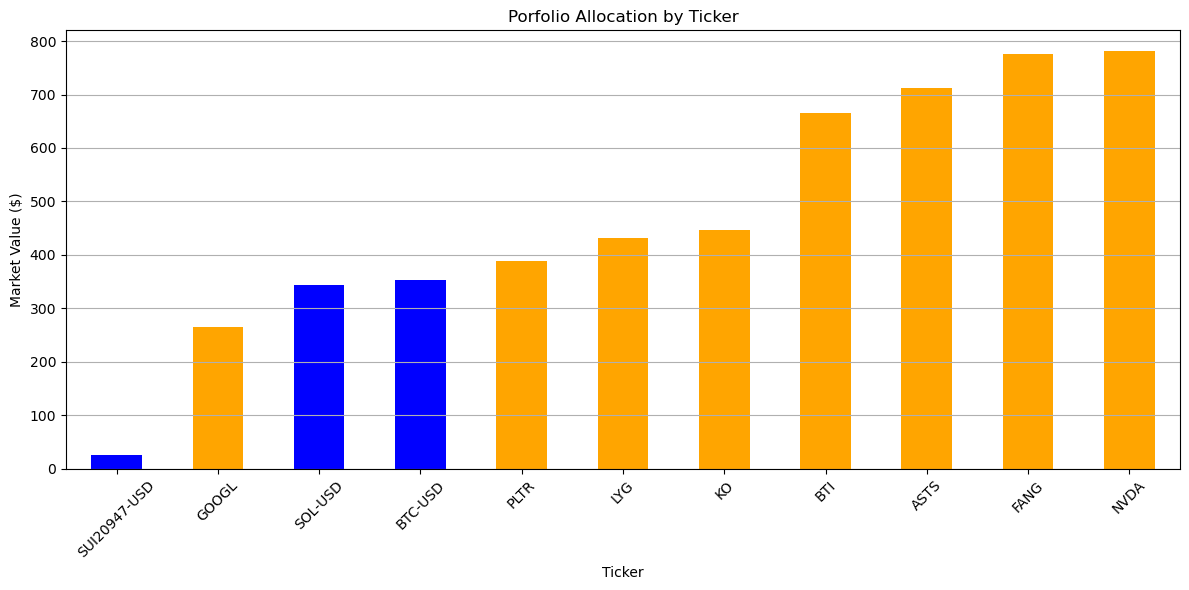

In [17]:
# Color ticker by asset
colors = [
    "orange" if ticker_asset_type[ticker] == "Equity" else "blue"
    for ticker in latest_positions.sort_values(ascending=True).index
]

# Distribution by ticker (Bar Chart - Value)
plt.figure(figsize=(12,6))
latest_positions.sort_values(ascending=True).plot(
    kind="bar",
    color=colors
)

plt.title("Porfolio Allocation by Ticker")
plt.xlabel("Ticker")
plt.ylabel("Market Value ($)")
plt.xticks(rotation=45)
plt.grid(True, axis="y")

plt.tight_layout()
plt.show()

C:\Users\Owner\AppData\Local\Temp\ipykernel_5216\1847303673.py:4: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(ticker_asset_type, axis=1)


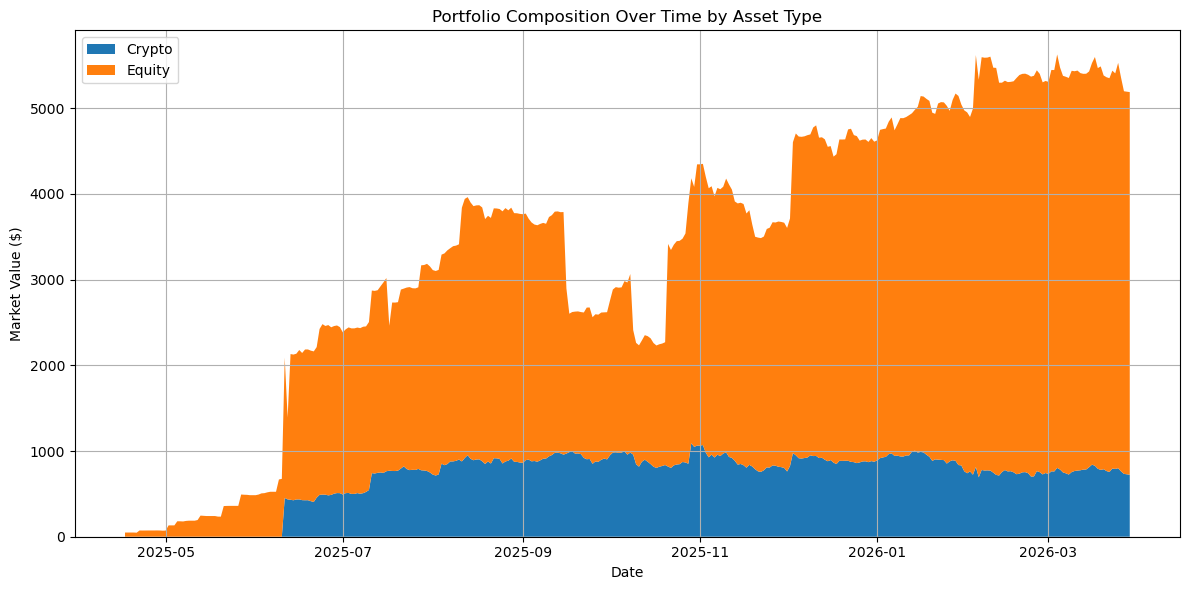

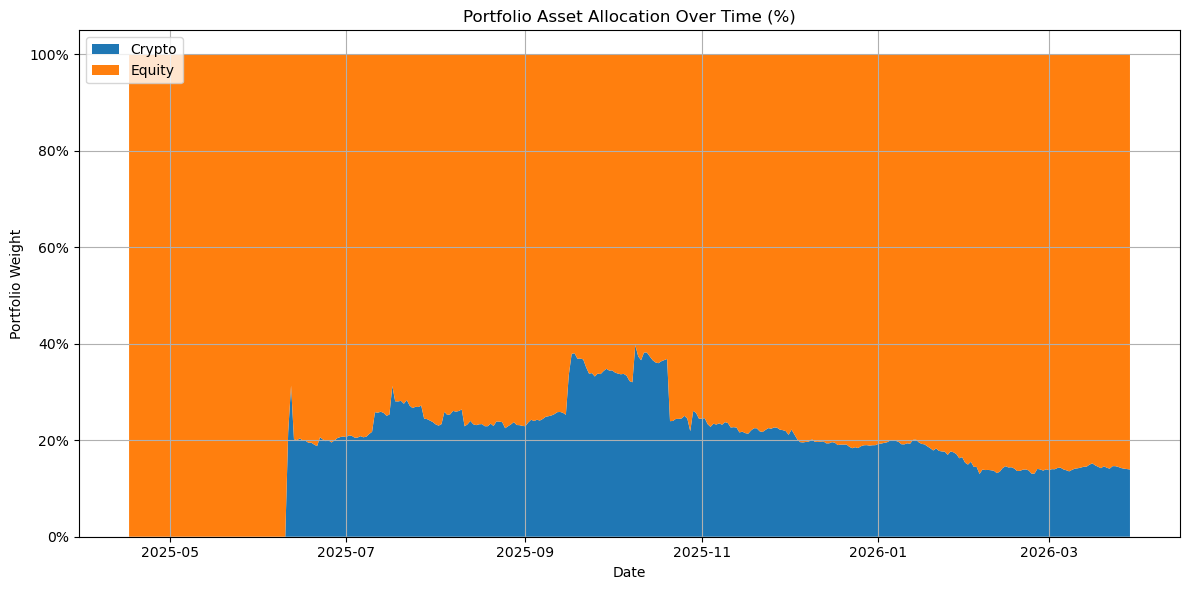

In [18]:
# Aggregate portfolio position values by Asset Type over time.
asset_type_over_time = (
    position_values
    .groupby(ticker_asset_type, axis=1)
    .sum()
)

# Plot portfolio composition over time using a stacked area chart.
plt.figure(figsize=(12, 6))
plt.stackplot(
    asset_type_over_time.index,
    asset_type_over_time.T.values,
    labels=asset_type_over_time.columns
)

plt.title("Portfolio Composition Over Time by Asset Type")
plt.xlabel("Date")
plt.ylabel("Market Value ($)")
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

#Plot Stacked % Over time

# Convert market values to portfolio weights (row-wise)
asset_type_pct = asset_type_over_time.div(
    asset_type_over_time.sum(axis=1),
    axis=0
)
asset_type_pct = asset_type_pct.fillna(0)

plt.figure(figsize=(12, 6))
plt.stackplot(
    asset_type_pct.index,
    asset_type_pct.T.values,
    labels=asset_type_pct.columns
)

plt.title("Portfolio Asset Allocation Over Time (%)")
plt.xlabel("Date")
plt.ylabel("Portfolio Weight")
plt.legend(loc="upper left")
plt.grid(True)

# Format y-axis as percentage
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

plt.tight_layout()
plt.show()


# Profit and Loss

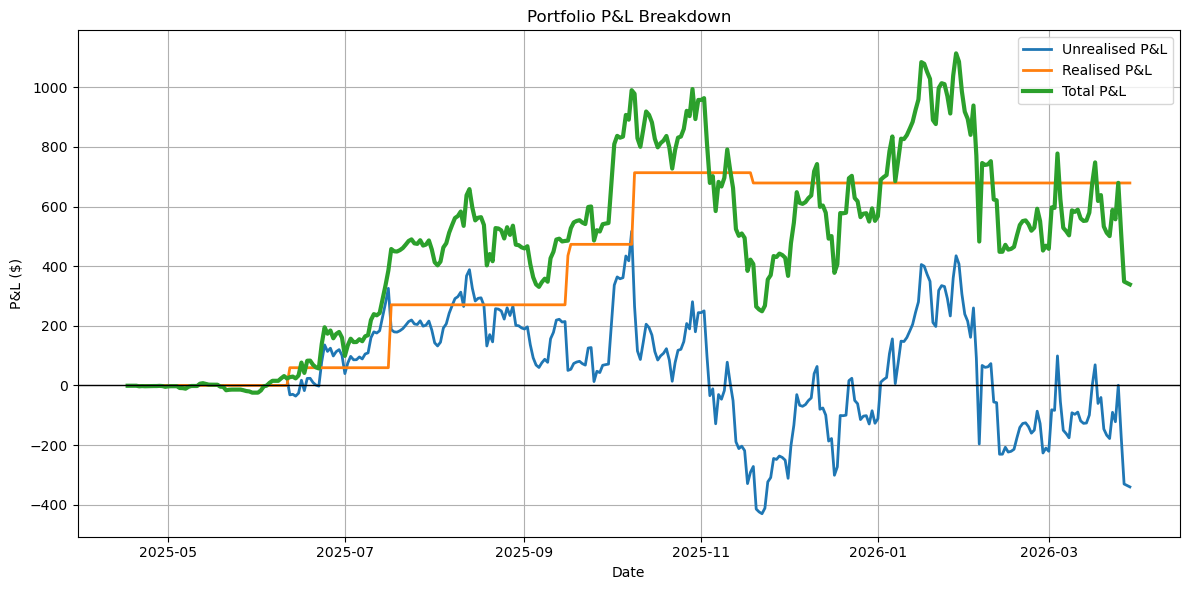

Current Unrealised G/L: -340.4248795717349
Current Realised G/L: 678.9326222401779
Total Current G/L: 338.50774266844303
Cost Basis G/L: -340.4248795717349


In [19]:
# Unrealised PnL
unrealised_pnl = portfolio_value - portfolio_cost_basis

# Realised PnL
realised_df = pd.DataFrame(realised_records)

realised_pnl = (
    realised_df
    .groupby("Date")["Realised_PnL"]
    .sum()
    .reindex(prices.index, fill_value=0)
    .cumsum()
)

# Total PnL
total_pnl= realised_pnl + unrealised_pnl

# Plot
plt.figure(figsize=(12, 6))

plt.plot(unrealised_pnl, label="Unrealised P&L", linewidth=2)
plt.plot(realised_pnl, label="Realised P&L", linewidth=2)
plt.plot(total_pnl, label="Total P&L", linewidth=3)

plt.axhline(0, color="black", linewidth=1)

plt.title("Portfolio P&L Breakdown")
plt.xlabel("Date")
plt.ylabel("P&L ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Holding Basis G/L
cost_basis_gnl = portfolio_value - portfolio_cost_basis

# PnL
print(f"Current Unrealised G/L: {unrealised_pnl.iloc[-1]}")
print(f"Current Realised G/L: {realised_pnl.iloc[-1]}")
print(f"Total Current G/L: {total_pnl.iloc[-1]}")
print(f"Cost Basis G/L: {cost_basis_gnl.iloc[-1]}")

# Return over time

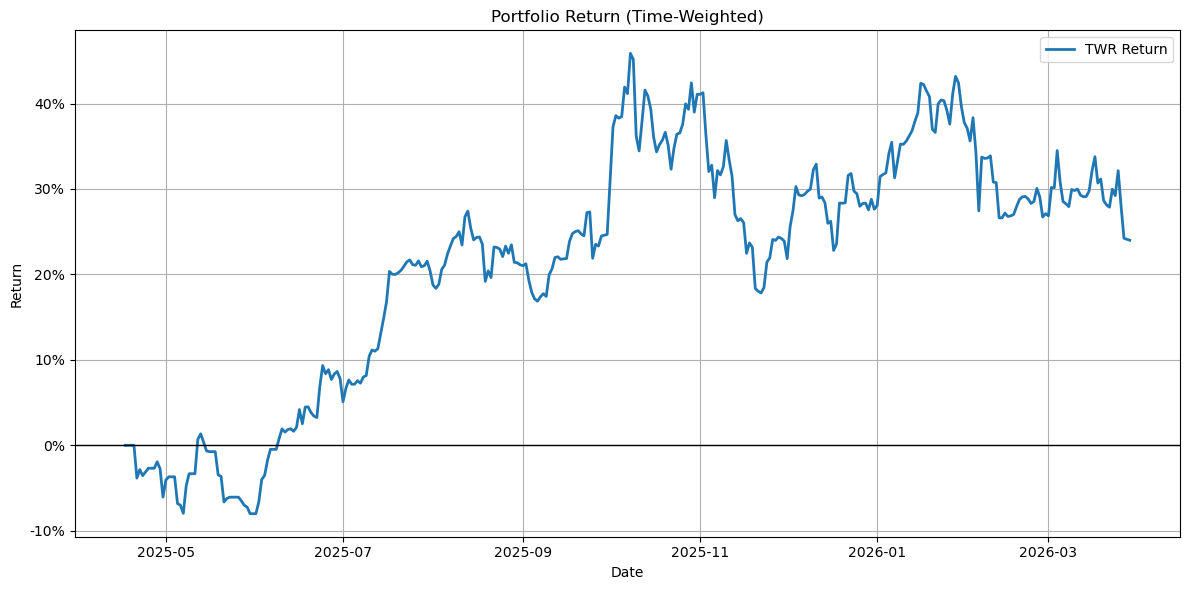

TWR: 24.00%


In [20]:
### TWR

# Daily Net CF
net_cash_flow = (
    tx.groupby("Date")["cash_flow"]
    .sum()
    .reindex(prices.index, fill_value=0)
)
# Reverse sign for TWR
net_cash_flow = -net_cash_flow

# TWR Return
portfolio_return = (
    (portfolio_value - (portfolio_value.shift(1) + net_cash_flow))
    / (portfolio_value.shift(1) + net_cash_flow)
)

# Clean numerical issues
portfolio_return = portfolio_return.replace([np.inf, -np.inf], 0).fillna(0)

# --------------------------
# Cumulative TWR
# --------------------------

cum_twr = (1 + portfolio_return).cumprod() - 1

# PLOT
plt.figure(figsize=(12,6))

plt.plot(cum_twr, label="TWR Return", linewidth=2)

plt.axhline(0, color="black", linewidth=1)

plt.title("Portfolio Return (Time-Weighted)")
plt.xlabel("Date")
plt.ylabel("Return")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f"{y:.0%}")
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"TWR: {cum_twr.iloc[-1]:.2%}")

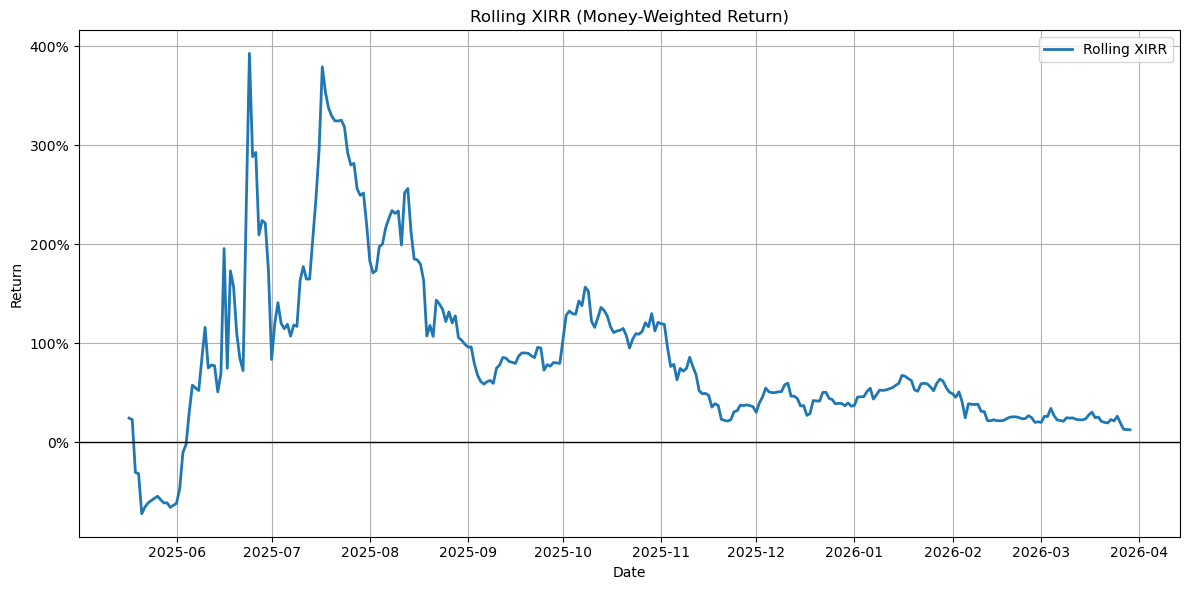

XIRR: 12.65%


In [21]:
### XIRR

# CF
cf = tx.groupby("Date")["cash_flow"].sum()

# Add final portfolio liquidation
cf = cf.copy()

# Add final liquidation value safely
final_date = portfolio_value.index[-1]
cf.loc[final_date] = cf.get(final_date, 0) + portfolio_value.iloc[-1]

cf = cf.sort_index()

# Convert dates to year
dates = cf.index
days = (dates - dates[0]).days / 365.25

# XIRR
def xirr(rate):
    return np.sum(cf.values / (1 + rate) ** days)

if (cf > 0).any() and (cf < 0).any():
    try:
        irr = brentq(xirr, -0.99, 10)
    except:
        irr = np.nan
else:
    irr = np.nan

# Over time
rolling_xirr = []

for i in range(30, len(portfolio_value)):
    
    # Build sub cash flow
    sub_cf = tx[tx["Date"] <= portfolio_value.index[i]]
    sub_cf = sub_cf.groupby("Date")["cash_flow"].sum().copy()
    
    date_i = portfolio_value.index[i]
    
    # Safe addition of portfolio value
    sub_cf.loc[date_i] = sub_cf.get(date_i, 0) + portfolio_value.iloc[i]
    
    sub_cf = sub_cf.sort_index()
    
    dates = sub_cf.index
    days = (dates - dates[0]).days / 365.25
    
    def f(rate):
        return np.sum(sub_cf.values / (1 + rate) ** days)
    
    # Ensure valid IRR inputs
    if (sub_cf > 0).any() and (sub_cf < 0).any():
        try:
            r = brentq(f, -0.99, 10)
        except:
            r = np.nan
    else:
        r = np.nan
    
    rolling_xirr.append(r)

rolling_xirr = pd.Series(
    rolling_xirr,
    index=portfolio_value.index[30:]
)

rolling_xirr = rolling_xirr.ffill()


# Plot
plt.figure(figsize=(12,6))

plt.plot(rolling_xirr, label="Rolling XIRR", linewidth=2)

plt.axhline(0, color="black", linewidth=1)

plt.title("Rolling XIRR (Money-Weighted Return)")
plt.xlabel("Date")
plt.ylabel("Return")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f"{y:.0%}")
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"XIRR: {irr:.2%}")

# Asset PnL Breakdown

In [22]:
# Latest and previous prices
last_prices = prices.iloc[-1]
prev_prices = prices.shift(1).iloc[-1]

# Optional: total dividend income by ticker
if "dividends_received_df" in locals():
    div_by_ticker = (
        dividends_received_df.groupby("Ticker")["Dividend_Received"]
        .sum()
    )
else:
    div_by_ticker = pd.Series(dtype=float)

# Sort transactions for inventory accounting
tx_summary = tx.sort_values(["Ticker", "Date"]).copy()

summary_records = []

for ticker, df in tx_summary.groupby("Ticker"):
    df = df.sort_values("Date")

    shares_held = 0.0
    cost_basis_open = 0.0

    realised_gain_usd = 0.0
    realised_cost_basis_sold = 0.0

    for _, row in df.iterrows():
        trade_type = row["Type"]
        qty = float(row["Shares"])
        px = float(row["Cost/Share ($)"])
        comm = float(row["Commn"]) if "Commn" in row and pd.notna(row["Commn"]) else 0.0

        if trade_type == "BUY":
            # Add shares and include buy commission in open cost basis
            shares_held += qty
            cost_basis_open += qty * px + comm

        elif trade_type == "SELL":
            if shares_held <= 0:
                continue

            avg_cost = cost_basis_open / shares_held

            # Cost basis of the sold shares
            sold_cost_basis = avg_cost * qty

            # Realised gain: proceeds - sold cost basis - sell commission
            realised_trade_gain = (qty * px) - sold_cost_basis - comm

            realised_gain_usd += realised_trade_gain
            realised_cost_basis_sold += sold_cost_basis

            # Remove sold inventory from open position
            shares_held -= qty
            cost_basis_open -= sold_cost_basis

            # Clean tiny floating point residue
            if abs(shares_held) < 1e-12:
                shares_held = 0.0
                cost_basis_open = 0.0

    # Current market data
    last_price = float(last_prices.get(ticker, 0.0))
    prev_price = float(prev_prices.get(ticker, last_price))

    market_value = shares_held * last_price
    prev_market_value = shares_held * prev_price

    # Average cost of remaining open shares
    ac_per_share = cost_basis_open / shares_held if shares_held > 0 else 0.0

    # Unrealised day gain
    day_gain_unrl_usd = shares_held * (last_price - prev_price)
    day_gain_unrl_pct = (
        day_gain_unrl_usd / prev_market_value
        if prev_market_value != 0 else 0.0
    )

    # Total unrealised gain
    tot_gain_unrl_usd = market_value - cost_basis_open
    tot_gain_unrl_pct = (
        tot_gain_unrl_usd / cost_basis_open
        if cost_basis_open != 0 else 0.0
    )

    # Realised gain %
    realised_gain_pct = (
        realised_gain_usd / realised_cost_basis_sold
        if realised_cost_basis_sold != 0 else 0.0
    )

    # Dividend income
    tot_div_income = float(div_by_ticker.get(ticker, 0.0))

    summary_records.append({
        "Ticker": ticker,
        "Shares": shares_held,
        "Last price": last_price,
        "AC/share": ac_per_share,
        "Total cost (US$)": cost_basis_open,
        "Market value (US$)": market_value,
        "Tot div income (US$)": tot_div_income,
        "Day gain UNRL (%)": day_gain_unrl_pct,
        "Day gain UNRL (US$)": day_gain_unrl_usd,
        "Tot gain UNRL (%)": tot_gain_unrl_pct,
        "Tot gain UNRL (US$)": tot_gain_unrl_usd,
        "Realised gain (%)": realised_gain_pct,
        "Realised gain (US$)": realised_gain_usd
    })

summary_df = pd.DataFrame(summary_records)

# Keep only assets currently held
summary_df = summary_df[summary_df["Shares"] > 0].copy()

# Sort by market value descending
summary_df = summary_df.sort_values("Market value (US$)", ascending=False).reset_index(drop=True)

In [23]:
# Keep raw summary_df for calculations
summary_display = summary_df.copy()

# Money columns -> 2 decimals
money_cols = [
    "Last price",
    "AC/share",
    "Total cost (US$)",
    "Market value (US$)",
    "Tot div income (US$)",
    "Day gain UNRL (US$)",
    "Tot gain UNRL (US$)",
    "Realised gain (US$)"
]

# Percentage columns -> 2 decimal places
pct_cols = [
    "Day gain UNRL (%)",
    "Tot gain UNRL (%)",
    "Realised gain (%)"
]

# Format for display
for col in money_cols:
    summary_display[col] = summary_display[col].map(lambda x: f"${x:,.2f}")

for col in pct_cols:
    summary_display[col] = summary_display[col].map(lambda x: f"{x:.2%}")

# Keep shares precise
summary_display["Shares"] = summary_display["Shares"].map(lambda x: f"{x:,.6f}")

summary_display

,Ticker,Shares,Last price,AC/share,Total cost (US$),Market value (US$),Tot div income (US$),Day gain UNRL (%),Day gain UNRL (US$),Tot gain UNRL (%),Tot gain UNRL (US$),Realised gain (%),Realised gain (US$)
0,NVDA,4.662270,$167.52,$180.37,$840.93,$781.02,$0.00,0.00%,$0.00,-7.12%,$-59.90,22.37%,$91.41
1,FANG,3.846214,$201.84,$150.21,$577.74,$776.32,$0.00,0.00%,$0.00,34.37%,$198.58,5.00%,$9.25
2,ASTS,9.042617,$78.67,$70.63,$638.67,$711.38,$0.00,0.00%,$0.00,11.38%,$72.71,36.74%,$439.15
3,BTI,11.515618,$57.80,$53.76,$619.08,$665.60,$0.00,0.00%,$0.00,7.51%,$46.52,9.92%,$56.43
4,KO,5.889407,$75.71,$69.46,$409.10,$445.89,$0.00,0.00%,$0.00,8.99%,$36.79,0.00%,$0.00
5,LYG,89.413241,$4.83,$4.70,$420.68,$431.87,$0.00,0.00%,$0.00,2.66%,$11.19,0.00%,$0.00
6,PLTR,2.712120,$143.06,$161.25,$437.34,$388.00,$0.00,0.00%,$0.00,-11.28%,$-49.34,22.42%,$71.43
7,BTC-USD,0.005359,"$65,954.92","$109,330.52",$585.90,$353.45,$0.00,-0.55%,$-1.95,-39.67%,$-232.45,0.00%,$0.00
8,SOL-USD,4.225896,$81.42,$130.68,$552.23,$344.08,$0.00,-0.72%,$-2.51,-37.69%,$-208.15,0.00%,$0.00
9,GOOGL,0.963790,$274.34,$327.77,$315.90,$264.41,$0.00,0.00%,$0.00,-16.30%,$-51.49,0.00%,$0.00


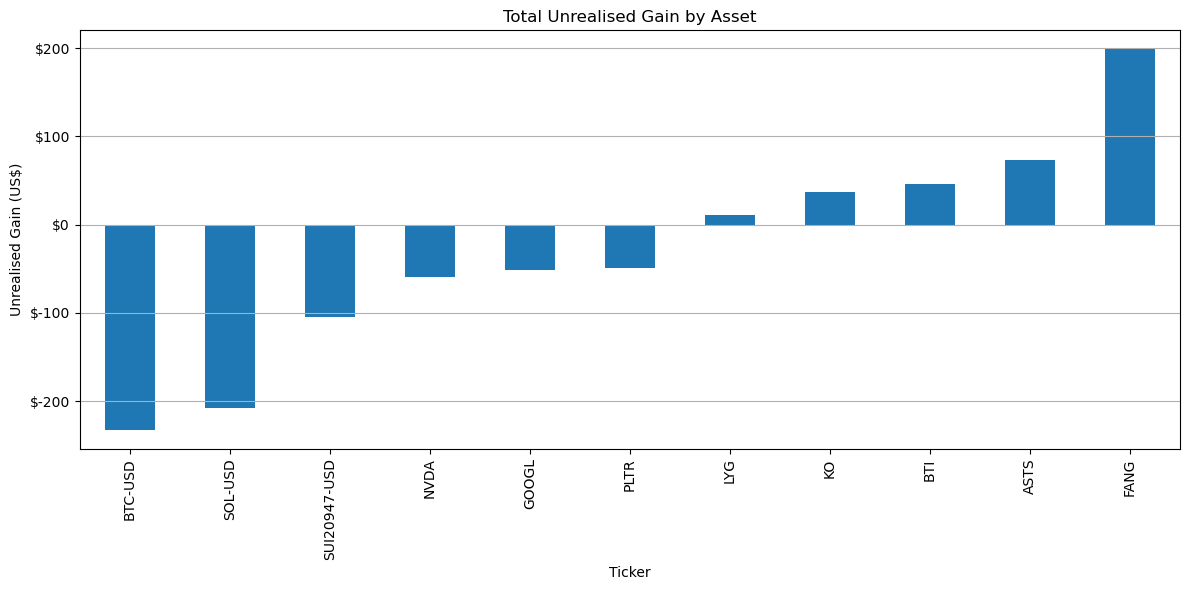

In [24]:
plt.figure(figsize=(12, 6))

summary_df.set_index("Ticker")["Tot gain UNRL (US$)"].sort_values().plot(kind="bar")

plt.title("Total Unrealised Gain by Asset")
plt.xlabel("Ticker")
plt.ylabel("Unrealised Gain (US$)")
plt.grid(True, axis="y")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x:,.0f}")
)

plt.tight_layout()
plt.show()

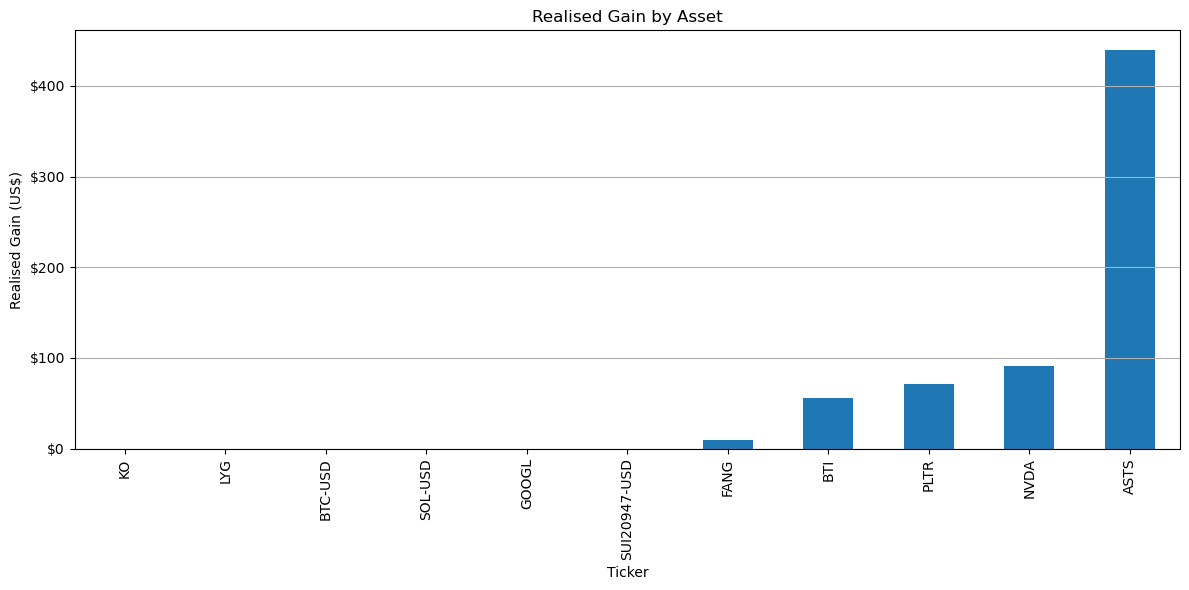

In [25]:
plt.figure(figsize=(12, 6))

summary_df.set_index("Ticker")["Realised gain (US$)"].sort_values().plot(kind="bar")

plt.title("Realised Gain by Asset")
plt.xlabel("Ticker")
plt.ylabel("Realised Gain (US$)")
plt.grid(True, axis="y")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x:,.0f}")
)

plt.tight_layout()
plt.show()

# Dividends

In [26]:
# DIV history for each ticker
dividend_records = []

for ticker in filt_tickers:
    try:
        div_series = yf.Ticker(ticker).dividends

        if div_series.empty:
            continue

        div_df = div_series.reset_index()
        div_df.columns = ["Date", "Dividend_per_share"]
        div_df["Ticker"] = ticker

        dividend_records.append(div_df)

    except Exception as e:
        print(f"Could not download dividends for {ticker}: {e}")

# Combine all dividend histories
if dividend_records:
    dividends_df = pd.concat(dividend_records, ignore_index=True)
else:
    dividends_df = pd.DataFrame(columns=["Date", "Dividend_per_share", "Ticker"])

dividends_df["Date"] = pd.to_datetime(dividends_df["Date"])
dividends_df = dividends_df.sort_values(["Ticker", "Date"])
dividends_df["Date"] = pd.to_datetime(dividends_df["Date"]).dt.tz_localize(None).dt.normalize()
tx["Date"] = pd.to_datetime(tx["Date"]).dt.normalize()
daily_holdings.index = pd.to_datetime(daily_holdings.index).normalize()

In [27]:
# Determine the number of shares held on each div date
dividend_records_with_shares = []


for _, row in dividends_df.iterrows():
    ticker = row["Ticker"]
    div_date = row["Date"]

    # If ticker exists in daily_holdings and date exists in index
    if ticker in daily_holdings.columns and div_date in daily_holdings.index:
        shares_held = daily_holdings.loc[div_date, ticker]
    else:
        shares_held = 0

    dividend_records_with_shares.append(shares_held)

dividends_df["Shares_Held"] = dividend_records_with_shares

In [28]:
# Compute div received
# ------------------------------------------------------------
# Dividend received = dividend per share × shares held
# ------------------------------------------------------------
dividends_df["Dividend_Received"] = (
    dividends_df["Dividend_per_share"] * dividends_df["Shares_Held"]
)

# Keep only positive dividend receipts
dividends_received_df = dividends_df[dividends_df["Dividend_Received"] > 0].copy()

In [29]:
# Total Div Received
monthly_dividends = (
    dividends_received_df
    .groupby(dividends_received_df["Date"].dt.to_period("M"))["Dividend_Received"]
    .sum()
)

monthly_dividends.index = monthly_dividends.index.to_timestamp()
monthly_dividend_table = monthly_dividends.to_frame(name="Monthly_Dividend_Received")
monthly_dividend_table["Cumulative_Dividends"] = monthly_dividend_table["Monthly_Dividend_Received"].cumsum()

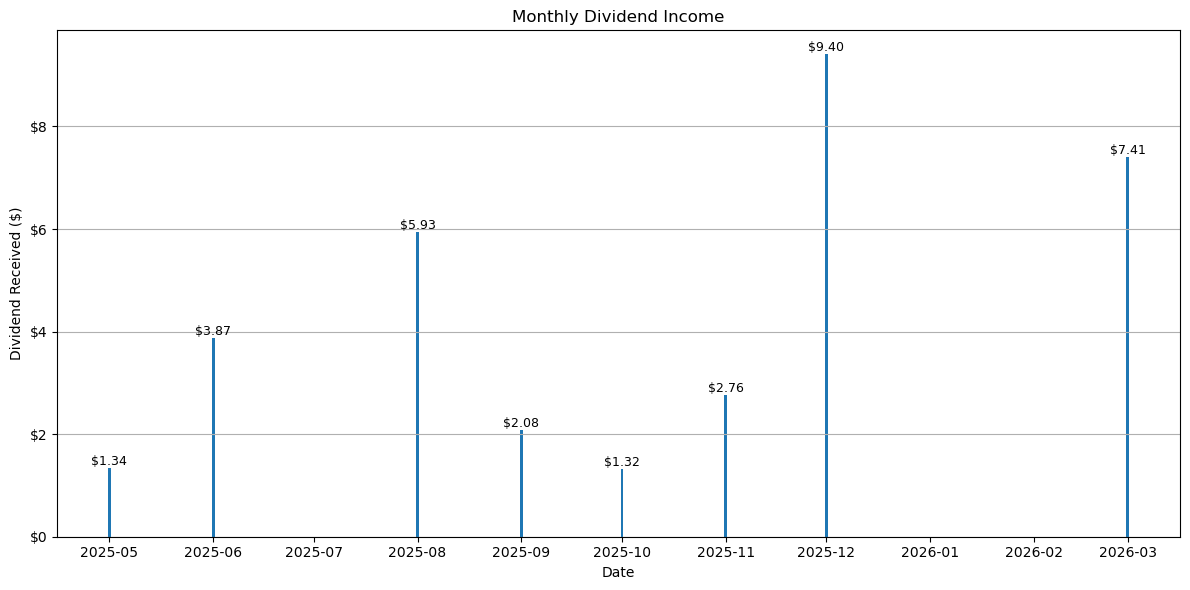

Total Dividends Received: $34.12


In [30]:
plt.figure(figsize=(12, 6))

plt.bar(
    monthly_dividends.index,
    monthly_dividends.values
)

plt.title("Monthly Dividend Income")
plt.xlabel("Date")
plt.ylabel("Dividend Received ($)")
plt.grid(True, axis="y")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x:,.0f}")
)

# Value labels
for x, y in zip(monthly_dividends.index, monthly_dividends.values):
    if y > 0:
        plt.text(
            x,
            y,
            f"${y:,.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

# Total div
total_dividends = dividends_received_df["Dividend_Received"].sum()
print(f"Total Dividends Received: ${total_dividends:,.2f}")